# Modelagem baseline — classificação binária de desempenho da escola (IDEB)

Com a base de modelagem fechada no `src/preprocessing/pipeline.py` (47 features,
38 numéricas e 9 categóricas, todas as escolas com `ideb` preenchido), a próxima
etapa é treinar um primeiro conjunto de modelos de classificação e ver o quanto dá
pra acertar `alvo_ideb` (1 se `ideb >= 6.0`) só com as informações estruturais e de
infraestrutura da escola.

Uso aqui os quatro modelos de classificação binária mais comuns como ponto de
partida: Regressão Logística, Árvore de Decisão, SVM e Naive Bayes. A ideia não é
sair já otimizando hiperparâmetro nem buscando o modelo final — é estabelecer uma
referência simples, com os defaults de cada algoritmo (ou parâmetros mínimos, tipo
profundidade da árvore), pra depois comparar qualquer otimização contra essa base.

Reaproveito direto as funções de `src/preprocessing/pipeline.py`
(`carregar_dataset_modelagem` e `construir_preprocessador`) em vez de reconstruir
o pré-processamento aqui — assim treino/teste e o pipeline de imputação/encoding
ficam idênticos ao que já validei naquele módulo.


### Escala das features: por que dois pré-processadores

Regressão Logística e SVM são modelos baseados em distância/gradiente, então a
escala das features numéricas afeta o resultado — sem `StandardScaler`, uma
coluna como `quantidade_desktop_aluno` (que varia de 0 a centenas) dominaria o
cálculo frente a uma flag binária de 0/1. Já Árvore de Decisão e Naive Bayes não
são sensíveis a escala: a árvore decide por cortes (`<=` valor) que não mudam de
posição relativa se eu multiplicar a coluna por uma constante, e o Naive Bayes
Gaussiano estima média/variância por coluna, então escalar não muda a
probabilidade relativa entre classes.

Por isso adicionei um parâmetro `escalar_numericas` em
`construir_preprocessador()`: uso `True` pra Regressão Logística/SVM e `False`
pra Árvore/Naive Bayes, treinando os quatro na mesma lista de 47 features mas com
o tratamento de escala adequado a cada algoritmo.


In [1]:
import sys
sys.path.append("../..")

import time

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from src.preprocessing.pipeline import carregar_dataset_modelagem, construir_preprocessador
from src.evaluation.metricas import avaliar_modelo, comparar_modelos, relatorio_classificacao_modelos
from src.visualization.graficos import plot_arvore, plot_comparacao_modelos

pd.set_option("display.max_columns", 100)


## 1. Carregando o dataset de modelagem

Mesma função usada no teste rápido do `pipeline.py`: filtra só escolas com
`ideb` preenchido e devolve `X` (as 47 features finais) e `y` (`alvo_ideb`).


In [2]:
X, y = carregar_dataset_modelagem()
print(f"X: {X.shape}, y: {y.shape}")
y.value_counts(normalize=True).round(3)


Lendo base_escola_modelo do cache local: /root/work/tech3/data/processed/base_escola_modelo.parquet


Escolas com ideb preenchido: 42273 de 63537 (66.5%) - só essas entram no dataset de modelagem.


acesso_internet_computador: 1009 escolas com código 9 (não informado) -> viraram nulo.
tratamento_lixo_inexistente: 57 escolas com código 9 (não informado) -> viraram nulo.
tratamento_lixo_reciclagem: 57 escolas com código 9 (não informado) -> viraram nulo.
redes_sociais: 546 escolas com código 9 (não informado) -> viraram nulo.
X: (42273, 47), y: (42273,)


alvo_ideb
1    0.548
0    0.452
Name: proportion, dtype: float64

## 2. Divisão treino/teste

`train_test_split` simples, com `stratify=y` pra manter a proporção de escolas
acima/abaixo do corte de IDEB em ambos os conjuntos, e `random_state=42` fixo pra
poder reproduzir. Essa é a decisão de chave de split que fechei no Achado 34 do
`reports/decisoes.md`: no grão escola cada linha já é uma escola só, diferente do
grão aluno (onde o mesmo município se repetia em muitas linhas e vazava
informação de treino pro teste), então não preciso agrupar o split por
município/UF aqui.

**Nota sobre a etapa seguinte (registrada aqui pra não perder o fio):** neste
notebook uso `X_teste`/`y_teste` pra comparar os quatro baselines. A partir da
próxima etapa (`10_otimizacao_modelo.ipynb`), esse mesmo conjunto (fixado pelo
`random_state=42`, então é sempre o mesmo recorte) passa a ser tratado como
**validação final, o "cofre fechado"**: não entra mais em nenhuma comparação de
hiperparâmetro, e só volto a usá-lo uma única vez, no fim, já com o modelo
escolhido, pra estimar a performance real de produção sem viés de eu ter
"espiado" o resultado repetidas vezes. A comparação entre os quatro modelos
aqui no baseline é a única exceção consciente a essa regra — e mesmo essa
comparação eu registro como uma pequena simplificação aceitável (Achado 37 em
`reports/decisoes.md`), não como o processo ideal.


In [3]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)
print(f"Treino: {X_treino.shape}")
print(f"Teste: {X_teste.shape}")


Treino: (33818, 47)
Teste: (8455, 47)


## 3. Pré-processamento: versão escalada e versão bruta

Ajusto os dois `ColumnTransformer` só no treino (`fit_transform`) e aplico no
teste (`transform`), pra não vazar estatística do teste (média/mediana/desvio)
pro ajuste.


In [4]:
preprocessador_escalado = construir_preprocessador(escalar_numericas=True)
X_treino_escalado = preprocessador_escalado.fit_transform(X_treino)
X_teste_escalado = preprocessador_escalado.transform(X_teste)

preprocessador_bruto = construir_preprocessador(escalar_numericas=False)
X_treino_bruto = preprocessador_bruto.fit_transform(X_treino)
X_teste_bruto = preprocessador_bruto.transform(X_teste)

print(f"Escalado -> treino {X_treino_escalado.shape}, teste {X_teste_escalado.shape}")
print(f"Bruto -> treino {X_treino_bruto.shape}, teste {X_teste_bruto.shape}")


Escalado -> treino (33818, 96), teste (8455, 96)
Bruto -> treino (33818, 96), teste (8455, 96)


As quatro formas acima saem com o **mesmo formato** (mesmo número de
linhas e colunas) nas duas versões - o que faz sentido, porque nenhuma das duas
adiciona ou remove coluna, e as 96 colunas finais vêm de 38 numéricas + 58
colunas geradas pelo One-Hot das 9 categóricas (isso é idêntico nos dois
`ColumnTransformer`, porque o pedaço categórico é igual nos dois). A diferença
entre "escalado" e "bruto" não está no formato, está nos **valores**: no bruto,
uma coluna de contagem continua na escala original (`11`, `17`, `32`...); no
escalado, a mesma coluna vira `z-score` (média 0, desvio padrão 1). Confirmo
isso abaixo comparando a primeira coluna numérica nas duas versões, pra não
ficar só na afirmação.


In [5]:
print("Primeira coluna numérica, 5 primeiras linhas do treino:")
print("bruto   :", X_treino_bruto[:5, 0])
print("escalado:", X_treino_escalado[:5, 0])


Primeira coluna numérica, 5 primeiras linhas do treino:
bruto   : [11. 17. 32. 15.  8.]
escalado: [-0.26984496  0.42225866  2.15251773  0.19155745 -0.61589678]


## 4. Treinando os quatro modelos baseline

Uso os defaults do `scikit-learn` pra cada modelo, exceto na Árvore de Decisão
(`max_depth=4`, pra manter a árvore legível quando eu visualizar) - ajuste fino
de hiperparâmetro fica pra próxima etapa, depois de ter essa referência baseline.

- **Regressão Logística**: baseline linear, cada coeficiente é interpretável
  como o efeito de uma feature na chance (log-odds) de bater a meta de IDEB.
- **Árvore de Decisão**: baseline não-linear, aprende regras tipo "se
  `X <= valor`", fácil de visualizar e explicar.
- **SVM (kernel RBF)**: tenta achar a fronteira de separação com maior margem
  entre as duas classes; mais caro computacionalmente (na base de ~34 mil
  escolas de treino, o fit sozinho leva cerca de 1 a 2 minutos aqui).
- **Naive Bayes (Gaussiano)**: baseline probabilístico rápido, assume as
  features independentes entre si dado o alvo — assunção forte pra um dataset
  com várias colunas de infraestrutura correlacionadas, mas serve de piso de
  comparação.


In [6]:
modelo_log = LogisticRegression(max_iter=1000)
modelo_log.fit(X_treino_escalado, y_treino)
resultado_log = avaliar_modelo(modelo_log, X_teste_escalado, y_teste, "Regressão Logística")


Acurácia Regressão Logística: 0.7374


A matriz de confusão cruza o que o modelo previu com o que de fato aconteceu:
cada linha é a classe real (0 = não bateu a meta, 1 = bateu), cada coluna é a
classe prevista. A diagonal principal são os acertos (verdadeiro negativo e
verdadeiro positivo); fora da diagonal são os dois tipos de erro (falso positivo
e falso negativo).


In [7]:
print(confusion_matrix(y_teste, resultado_log["previsoes"]))


[[2555 1271]
 [ 949 3680]]


In [8]:
modelo_arvore = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_arvore.fit(X_treino_bruto, y_treino)
resultado_arvore = avaliar_modelo(modelo_arvore, X_teste_bruto, y_teste, "Árvore de Decisão")


Acurácia Árvore de Decisão: 0.6746


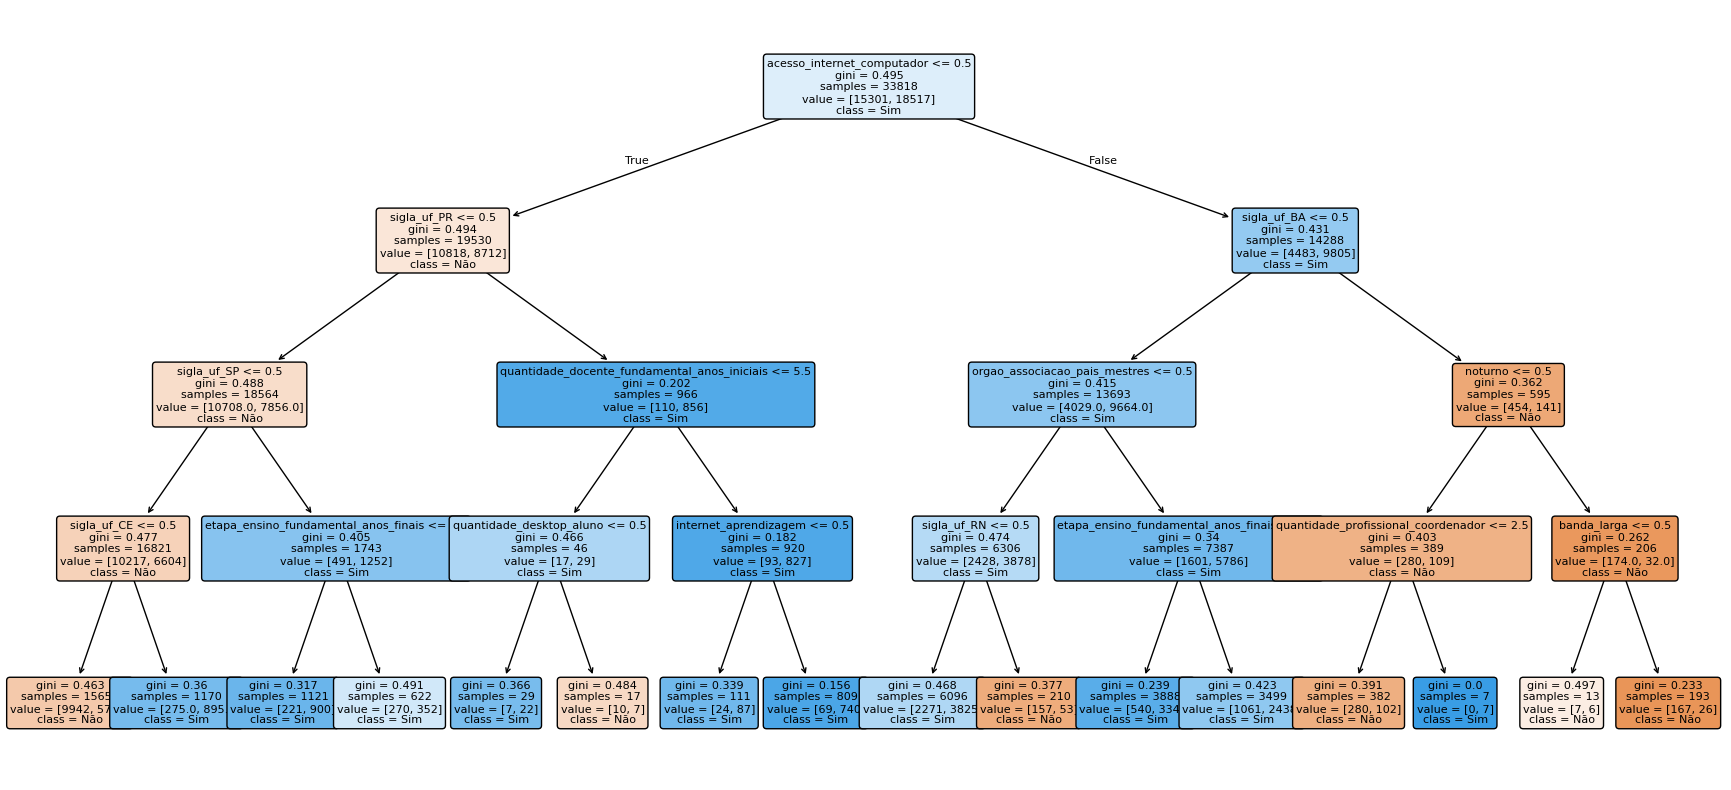

In [9]:
plot_arvore(modelo_arvore, preprocessador_bruto.get_feature_names_out())


In [10]:
inicio = time.time()
modelo_svm = SVC(kernel="rbf")
modelo_svm.fit(X_treino_escalado, y_treino)
resultado_svm = avaliar_modelo(modelo_svm, X_teste_escalado, y_teste, "SVM")
print(f"Tempo de treino: {time.time() - inicio:.1f}s")


Acurácia SVM: 0.7489
Tempo de treino: 214.3s


In [11]:
modelo_nb = GaussianNB()
modelo_nb.fit(X_treino_bruto, y_treino)
resultado_nb = avaliar_modelo(modelo_nb, X_teste_bruto, y_teste, "Naive Bayes")


Acurácia Naive Bayes: 0.6546


## 5. Comparação entre os modelos


In [12]:
resultados = comparar_modelos({
    "Regressão Logística": resultado_log["acuracia"],
    "Árvore de Decisão": resultado_arvore["acuracia"],
    "SVM": resultado_svm["acuracia"],
    "Naive Bayes": resultado_nb["acuracia"],
})
resultados


,Modelo,Acurácia
0,SVM,0.748906
1,Regressão Logística,0.737433
2,Árvore de Decisão,0.674630
3,Naive Bayes,0.654642


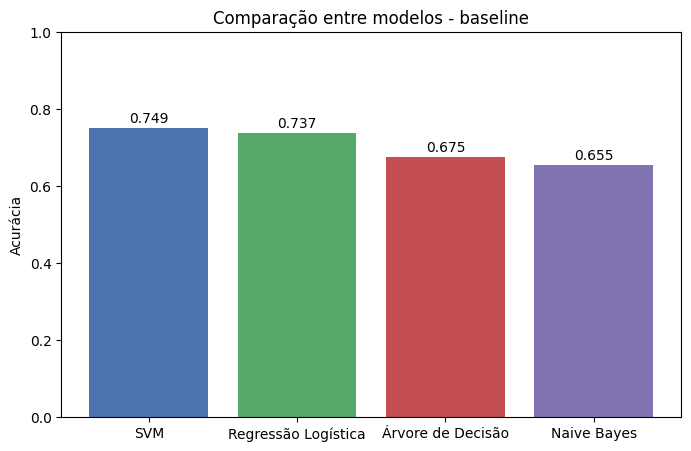

In [13]:
plot_comparacao_modelos(resultados, titulo="Comparação entre modelos - baseline")


## 6. Relatório de classificação completo

Acurácia sozinha esconde desbalanceamento entre as classes (aqui é ~55%/45%, não
é grave, mas ainda assim vale olhar precisão/recall por classe pra cada modelo,
principalmente pra ver se algum deles está só "chutando" a classe majoritária.


In [14]:
previsoes = {
    "Regressão Logística": resultado_log["previsoes"],
    "Árvore de Decisão": resultado_arvore["previsoes"],
    "SVM": resultado_svm["previsoes"],
    "Naive Bayes": resultado_nb["previsoes"],
}

relatorio_classificacao_modelos(previsoes, y_teste)


=== Regressão Logística ===
              precision    recall  f1-score   support

         Não       0.73      0.67      0.70      3826
         Sim       0.74      0.79      0.77      4629

    accuracy                           0.74      8455
   macro avg       0.74      0.73      0.73      8455
weighted avg       0.74      0.74      0.74      8455

=== Árvore de Decisão ===
              precision    recall  f1-score   support

         Não       0.63      0.68      0.65      3826
         Sim       0.72      0.67      0.69      4629

    accuracy                           0.67      8455
   macro avg       0.67      0.67      0.67      8455
weighted avg       0.68      0.67      0.68      8455

=== SVM ===
              precision    recall  f1-score   support

         Não       0.74      0.69      0.71      3826
         Sim       0.76      0.80      0.78      4629

    accuracy                           0.75      8455
   macro avg       0.75      0.74      0.75      8455
weighted

              precision    recall  f1-score   support

         Não       0.79      0.32      0.46      3826
         Sim       0.62      0.93      0.75      4629

    accuracy                           0.65      8455
   macro avg       0.71      0.63      0.60      8455
weighted avg       0.70      0.65      0.62      8455



## 7. Síntese

Com os quatro baselines rodados, SVM e Regressão Logística ficaram à frente da
Árvore de Decisão e do Naive Bayes nessa primeira rodada, o que faz sentido: são
os dois modelos que usam a versão escalada das features numéricas e conseguem
combinar informação de várias colunas de forma mais suave que uma árvore rasa
(`max_depth=4`) ou uma assunção de independência total entre features
(Naive Bayes). A Árvore, mesmo limitada em profundidade, ainda serve de
referência interpretável — dá pra ler direto no gráfico quais cortes ela está
usando pra separar as classes.

Nenhum desses quatro modelos passou por ajuste de hiperparâmetro além do
`max_depth=4` da árvore (que fixei só pra manter o gráfico legível). Essa é a
etapa seguinte: otimizar o(s) modelo(s) mais promissores dessa comparação e
avaliar generalização com mais cuidado (validação cruzada, curva de
aprendizado, análise de overfitting), além de olhar importância de feature
(coeficientes da Regressão Logística, `feature_importances_` da árvore, e
possivelmente SHAP) pra entender quais características da escola mais pesam
na previsão.
